**Social Media engagement EDA** -Suravi Poudel

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("social_media_engagement1.csv")
df.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,post_id,likes,comments,shares
count,100.000000,100.000000,100.00000,100.000000
mean,50.500000,2381.810000,202.66000,415.650000
std,29.011492,1632.573284,138.84067,283.877601
min,1.000000,15.000000,10.00000,16.000000
25%,25.750000,895.750000,89.75000,183.000000
50%,50.500000,2220.000000,171.00000,356.500000
75%,75.250000,3593.250000,299.00000,689.500000
max,100.000000,5000.000000,500.00000,993.000000


In [ ]:
df.isnull().sum()

,0
post_id,0
platform,0
post_type,0
post_time,0
likes,0
comments,0
shares,0
post_day,0
sentiment_score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.dropna()
df.columns = df.columns.str.lower()

In [ ]:
print(df.columns)

Index(['post_id', 'platform', 'post_type', 'post_time', 'likes', 'comments',
       'shares', 'post_day', 'sentiment_score'],
      dtype='object')


In [ ]:
df.rename(columns={
    "likes": "Likes",
    "shares": "Shares",
    "comments": "Comments"
}, inplace=True)

In [ ]:
for col in df.columns:
    print(repr(col))

'post_id'
'platform'
'post_type'
'post_time'
'Likes'
'Comments'
'Shares'
'post_day'
'sentiment_score'


In [ ]:
total_likes    = df["Likes"].sum()
total_shares   = df["Shares"].sum()
total_comments = df["Comments"].sum()

print("Total Likes:", total_likes)
print("Total Shares:", total_shares)
print("Total Comments:", total_comments)

Total Likes: 238181
Total Shares: 41565
Total Comments: 20266


In [ ]:
print("Average Likes:", df['Likes'].mean())
print("Average Comments:", df['Comments'].mean())
print("Average Shares:", df['Shares'].mean())

Average Likes: 2381.81
Average Comments: 202.66
Average Shares: 415.65


In [ ]:
df['engagement'] = df['Likes'] + df['Comments'] + df['Shares']

In [ ]:
top_posts = df.sort_values(by='engagement', ascending=False)
top_posts.head(10)

,post_id,platform,post_type,post_time,Likes,Comments,Shares,post_day,sentiment_score,engagement
38,39,Facebook,video,1/1/2023 6:00,5000,430,980,Sunday,neutral,6410
30,31,Facebook,poll,9/10/2023 13:45,4795,449,978,Sunday,negative,6222
73,74,Instagram,video,4/14/2023 10:30,5000,454,744,Friday,positive,6198
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,6051
59,60,Instagram,carousel,5/19/2023 4:30,4763,332,956,Friday,positive,6051
82,83,Instagram,video,12/6/2023 4:00,5000,173,792,Wednesday,negative,5965
41,42,Instagram,video,11/23/2023 2:00,4929,252,730,Thursday,negative,5911
74,75,Facebook,video,7/26/2023 20:15,5000,500,404,Wednesday,positive,5904
46,47,Facebook,poll,8/8/2023 17:45,4726,44,993,Tuesday,negative,5763
81,82,Instagram,carousel,11/19/2023 12:30,4656,314,757,Sunday,negative,5727


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


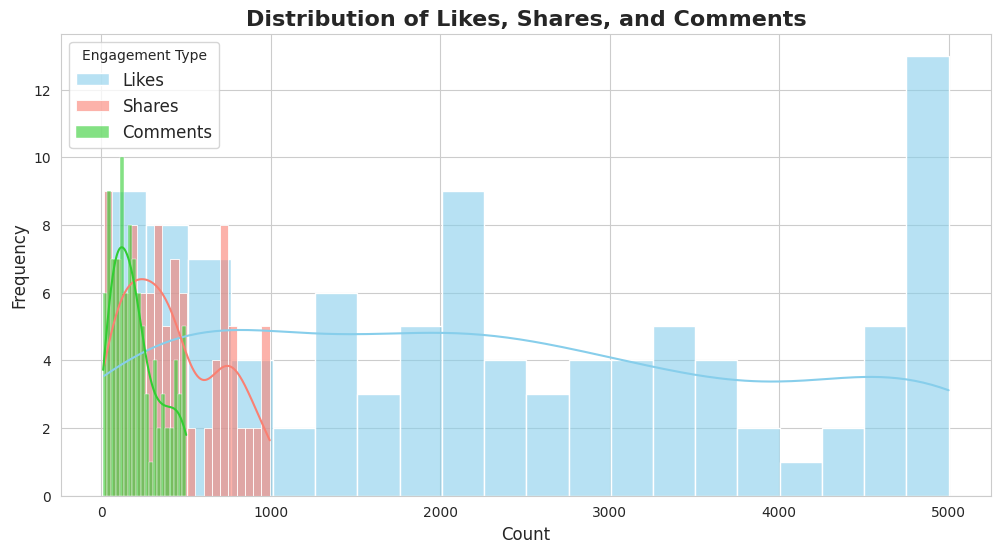

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# Plot distributions with transparency
sns.histplot(df["Likes"], color="skyblue", label="Likes", kde=True, alpha=0.6, bins=20)
sns.histplot(df["Shares"], color="salmon", label="Shares", kde=True, alpha=0.6, bins=20)
sns.histplot(df["Comments"], color="limegreen", label="Comments", kde=True, alpha=0.6, bins=20)

# Add labels and title
plt.xlabel("Count", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Likes, Shares, and Comments", fontsize=16, fontweight='bold')

# Show legend
plt.legend(title="Engagement Type", fontsize=12)
plt.show()

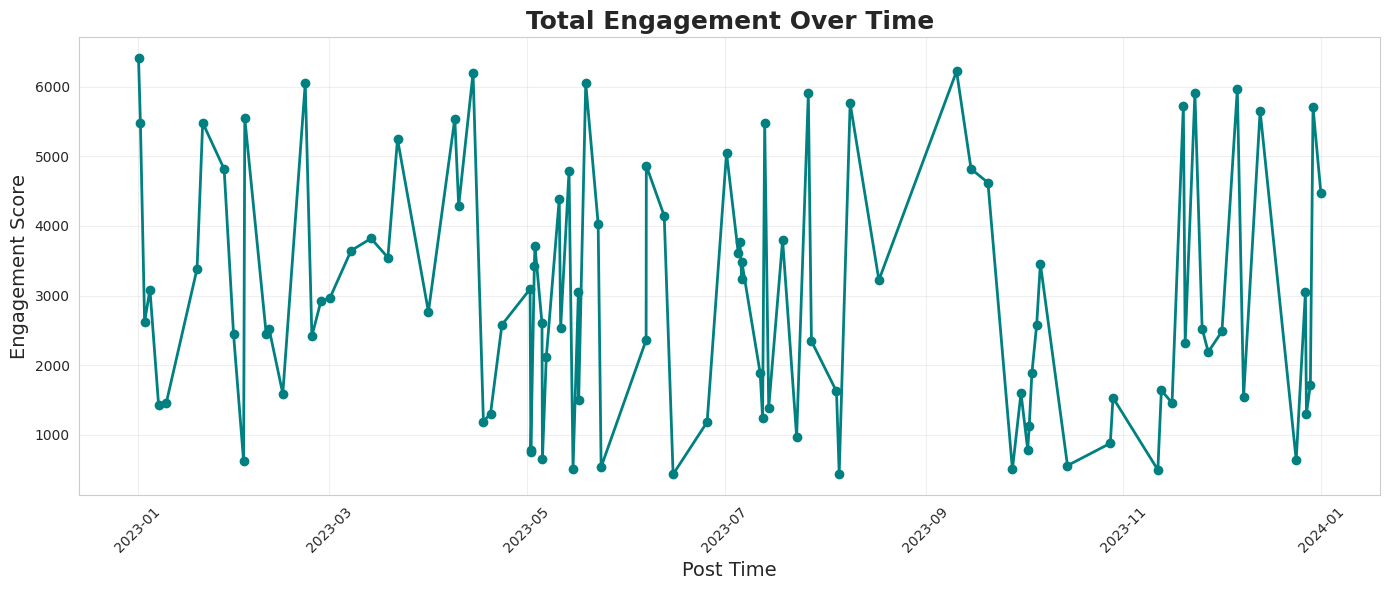

In [ ]:
# Set Seaborn style
sns.set_style("whitegrid")

# Ensure post_time is datetime and sorted
df['post_time'] = pd.to_datetime(df['post_time'])
df.sort_values(by='post_time', inplace=True)

plt.figure(figsize=(14,6))

# Plot engagement over time with markers
plt.plot(df['post_time'], df['engagement'], marker='o', linestyle='-', color='teal', markersize=6, linewidth=2)

# Title and labels
plt.title("Total Engagement Over Time", fontsize=18, fontweight='bold')
plt.xlabel("Post Time", fontsize=14)
plt.ylabel("Engagement Score", fontsize=14)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

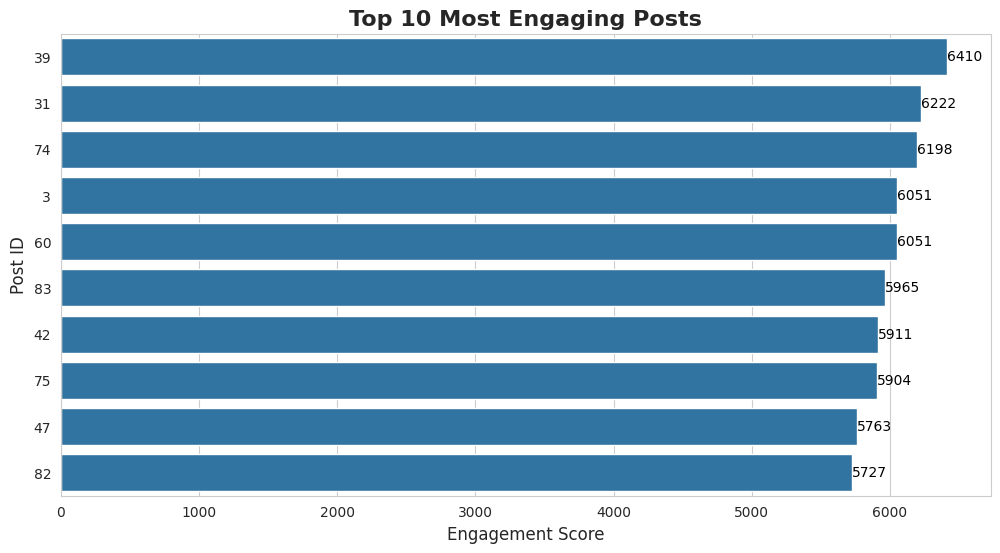

In [ ]:
# Ensure plots show in Colab
%matplotlib inline

# Top 10 posts by engagement
top_posts = df.sort_values(by="engagement", ascending=False).head(10)

# Convert post_id to string to ensure Seaborn plots it properly
top_posts['post_id'] = top_posts['post_id'].astype(str)

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(12,6))

# Horizontal barplot
barplot = sns.barplot(
    x="engagement",
    y="post_id",
    data=top_posts
)

# Add title and labels
plt.title("Top 10 Most Engaging Posts", fontsize=16, fontweight='bold')
plt.xlabel("Engagement Score", fontsize=12)
plt.ylabel("Post ID", fontsize=12)

# Add data labels at the end of each bar
for index, value in enumerate(top_posts['engagement']):
    barplot.text(value + 0.5, index, str(value), color='black', va='center')

plt.show()

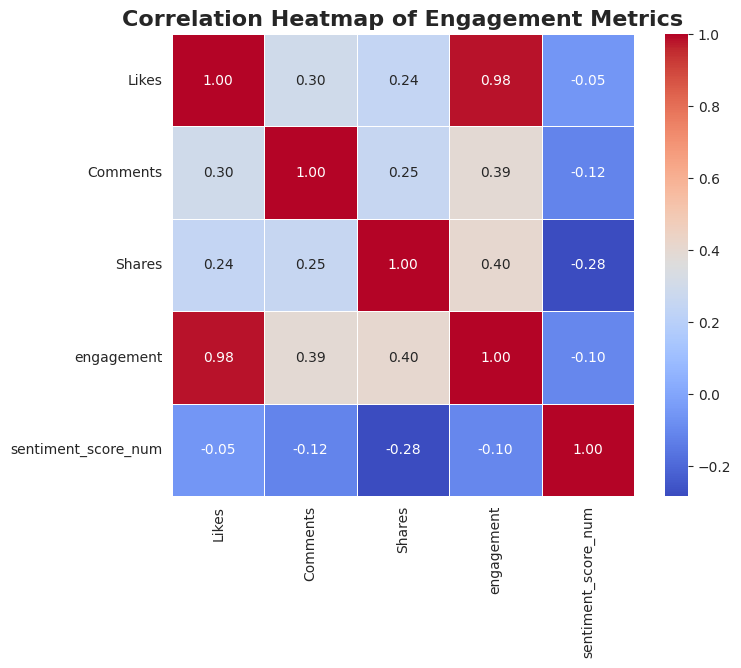

In [ ]:
# Map sentiment strings to numbers
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment_score_num'] = df['sentiment_score'].map(sentiment_map)

# Select numeric columns
numeric_cols = ['Likes', 'Comments', 'Shares', 'engagement', 'sentiment_score_num']

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Engagement Metrics", fontsize=16, fontweight='bold')
plt.show()

<Axes: xlabel='post_type', ylabel='engagement'>

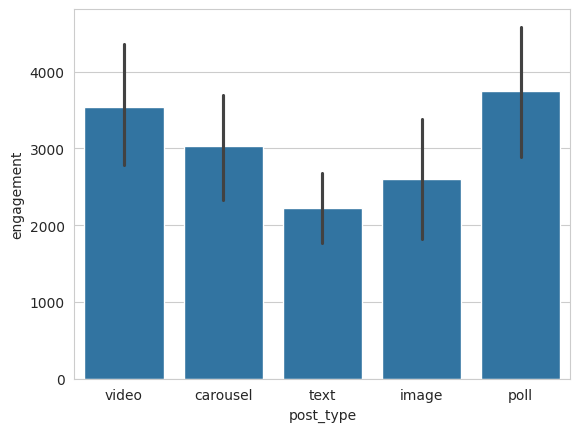

In [ ]:
sns.barplot(x='post_type', y='engagement', data=df)

<Axes: xlabel='sentiment_score', ylabel='engagement'>

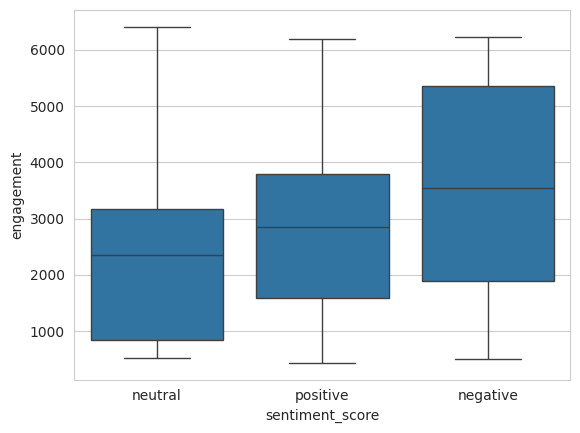

In [ ]:
sns.boxplot(x='sentiment_score', y='engagement', data=df)

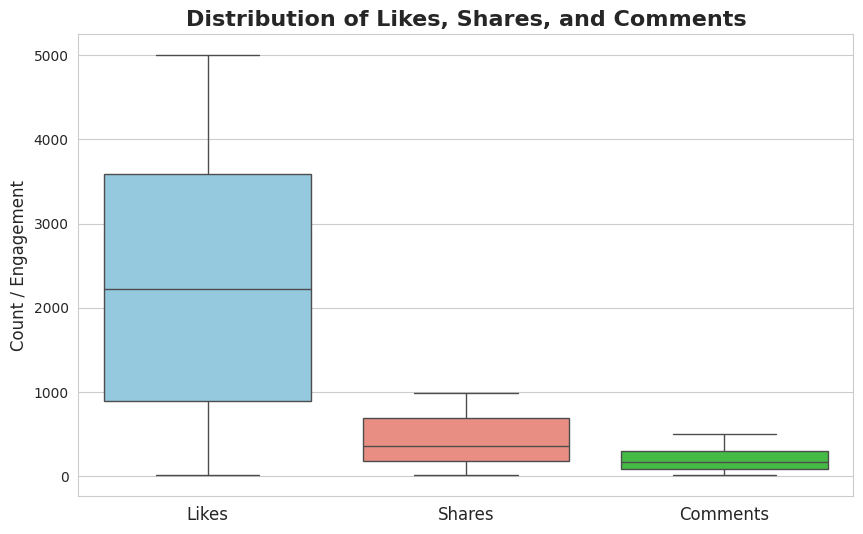

In [ ]:
plt.figure(figsize=(10,6))

# Create boxplot with labels
sns.boxplot(data=df[['Likes','Shares','Comments']],
            palette=["skyblue","salmon","limegreen"])

# Add x-axis labels
plt.xticks([0,1,2], ['Likes', 'Shares', 'Comments'], fontsize=12)

# Add y-axis label
plt.ylabel("Count / Engagement", fontsize=12)

# Add title
plt.title("Distribution of Likes, Shares, and Comments", fontsize=16, fontweight='bold')

plt.show()

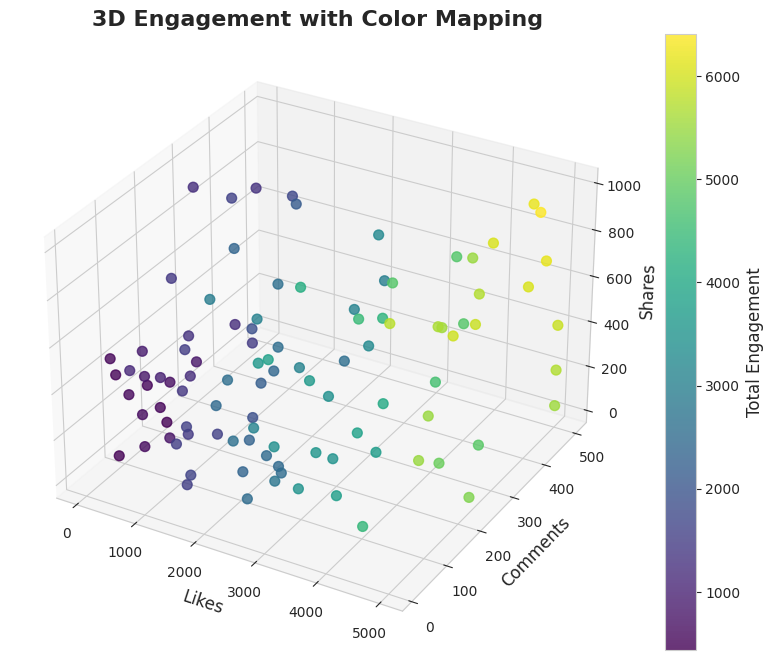

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

df['engagement'] = df['Likes'] + df['Comments'] + df['Shares']

# Create figure
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot
scatter = ax.scatter(
    df['Likes'],
    df['Comments'],
    df['Shares'],
    c=df['engagement'],          # Color by total engagement
    cmap='viridis',              # Color map from low->high
    s=50,                        # marker size
    alpha=0.8                    # transparency
)

# Labels
ax.set_xlabel('Likes', fontsize=12)
ax.set_ylabel('Comments', fontsize=12)
ax.set_zlabel('Shares', fontsize=12)

# Title
plt.title("3D Engagement with Color Mapping", fontsize=16, fontweight='bold')

# Color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Total Engagement', fontsize=12)

plt.show()

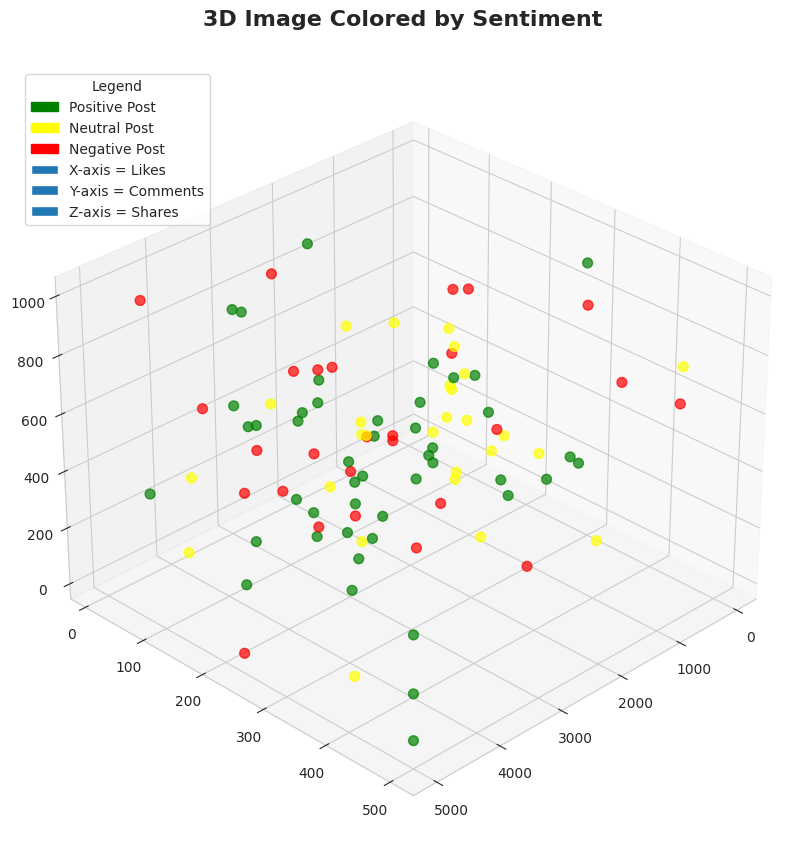

In [ ]:
# Map sentiment to colors
sentiment_map = {'positive':'green', 'neutral':'yellow', 'negative':'red'}
df['sentiment_color'] = df['sentiment_score'].map(sentiment_map)

# Create a larger figure
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot
scatter = ax.scatter(
    df['Likes'], df['Comments'], df['Shares'],
    c=df['sentiment_color'], s=50, alpha=0.7
)

# Remove axis labels but keep numeric ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

# Show numeric ticks only
ax.xaxis.set_tick_params(labelsize=10)
ax.yaxis.set_tick_params(labelsize=10)
ax.zaxis.set_tick_params(labelsize=10)

# Title
plt.title("3D Image Colored by Sentiment", fontsize=16, fontweight='bold', pad=30)

# Legend for sentiment only
positive_patch = mpatches.Patch(color='green', label='Positive Post')
neutral_patch  = mpatches.Patch(color='yellow', label='Neutral Post')
negative_patch = mpatches.Patch(color='red', label='Negative Post')

plt.legend(handles=[positive_patch, neutral_patch, negative_patch],
           title="Sentiment", loc='upper left', fontsize=10)
# Legend for axes
likes_patch    = mpatches.Patch(label='X-axis = Likes')
comments_patch = mpatches.Patch(label='Y-axis = Comments')
shares_patch   = mpatches.Patch(label='Z-axis = Shares')
# Combine legends
plt.legend(handles=[positive_patch, neutral_patch, negative_patch,
                    likes_patch, comments_patch, shares_patch],
           title="Legend", loc='upper left', fontsize=10)

# Rotate view for better perspective
ax.view_init(elev=30, azim=45)

plt.show()

In [ ]:
pip install kaleido

In [ ]:
import plotly.graph_objects as go

# Map sentiment to colors
sentiment_colors = {'positive': 'green', 'neutral': 'yellow', 'negative': 'red'}

# Create 3D scatter plot
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=df['Likes'],
    y=df['Comments'],
    z=df['Shares'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['sentiment_score'].map(sentiment_colors),  # map sentiment to color
        opacity=0.8
    ),
    text=[f"Likes: {l}<br>Comments: {c}<br>Shares: {s}<br>Sentiment: {snt}"
          for l, c, s, snt in zip(df['Likes'], df['Comments'], df['Shares'], df['sentiment_score'])],
    hoverinfo='text',
    name='Posts'
))

# Layout
fig.update_layout(
    title="3D Engagement Scatter with Sentiment",
    scene=dict(
        xaxis=dict(title='Likes'),
        yaxis=dict(title='Comments'),
        zaxis=dict(title='Shares'),
    ),
    legend_title_text='Sentiment',
    width=900,
    height=700,
    margin=dict(l=50, r=50, b=50, t=50)
)

# Display the figure inline in Jupyter Notebook
fig.show("notebook")  